# PINN Potential Flow over NACA 0009 at 5 Degrees

The final corrected Phase 4 implementation, including circulation, a pressure gauge, and a trailing-edge Kutta constraint.


CUDA: True  Device: cuda


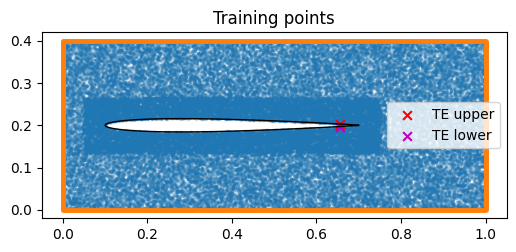

airfoil points: 80 normals: 80
It    200 | total=5.151e-01 | far=4.886e-03 | af=4.429e-02 | pde=2.288e-03 | k=1.088e-10 | Gamma=-0.0013 | wB=0.1
It    400 | total=4.878e-01 | far=4.309e-03 | af=4.397e-02 | pde=4.623e-04 | k=7.511e-09 | Gamma=-0.0015 | wB=0.1
It    600 | total=4.846e-01 | far=4.226e-03 | af=4.391e-02 | pde=3.050e-04 | k=1.292e-08 | Gamma=-0.0014 | wB=0.1
It    800 | total=4.836e-01 | far=4.186e-03 | af=4.390e-02 | pde=2.555e-04 | k=1.543e-08 | Gamma=-0.0011 | wB=0.1
It   1000 | total=4.830e-01 | far=4.159e-03 | af=4.389e-02 | pde=2.371e-04 | k=1.912e-08 | Gamma=-0.0010 | wB=0.1
It   1200 | total=4.826e-01 | far=4.139e-03 | af=4.388e-02 | pde=2.255e-04 | k=2.378e-08 | Gamma=-0.0009 | wB=0.1
It   1400 | total=4.822e-01 | far=4.125e-03 | af=4.387e-02 | pde=2.174e-04 | k=2.906e-08 | Gamma=-0.0008 | wB=0.1
It   1600 | total=4.819e-01 | far=4.114e-03 | af=4.385e-02 | pde=2.120e-04 | k=3.503e-08 | Gamma=-0.0008 | wB=0.1
It   1800 | total=4.816e-01 | far=4.107e-03 | af=4.383e-0

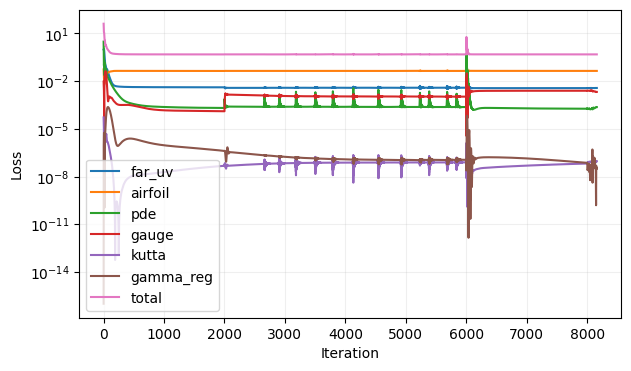

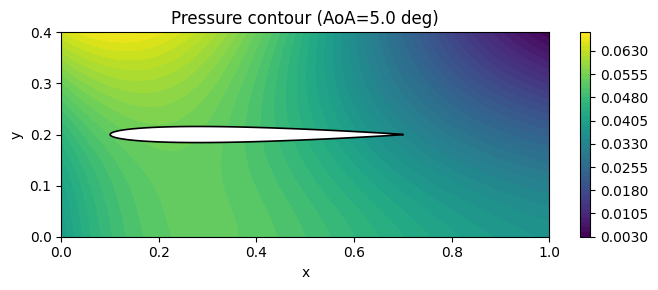

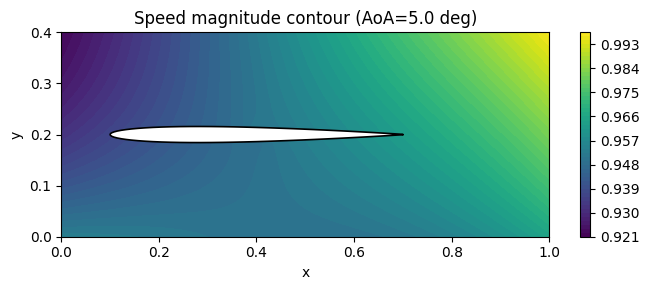

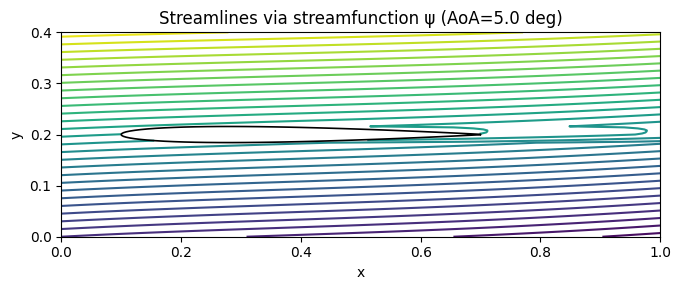


===== Pressure-force Lift/Drag (2D per unit span) =====
Chord c = 0.600000
Fx = 3.566168e-04, Fy = -6.320488e-05
Drag D = 3.497511e-04, Lift L = -9.404557e-05
CD = 1.165837e-03, CL = -3.134853e-04
Learned circulation Gamma = -0.000178


In [4]:
# ===================== Phase-4 (Final Fixed) =====================
# Potential Flow PINN over airfoil, AoA=5deg
# Fixes:
# - farfield: enforce only u,v (no p pinning)
# - pressure gauge point
# - robust TE point selection (top-k by x)
# - Kutta on tangential velocity near TE
# - learnable circulation Gamma via vortex field (center inside airfoil)
# - streamlines via streamfunction psi contours (no streamplot artifacts)
# ---------------------------------------------------------------


import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import grad
import time

try:
    from pyDOE import lhs
except Exception:
    from pyDOE import lhs

# ===================== Device & Seeds =====================
use_cuda = torch.cuda.is_available()
device = torch.device("cuda") if use_cuda else torch.device("cpu")
torch.manual_seed(1234)
np.random.seed(1234)
if use_cuda:
    torch.cuda.manual_seed_all(1234)

print("CUDA:", use_cuda, " Device:", device)

# --------------------- Domain ---------------------
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 0.4
ub = np.array([x_max, y_max], dtype=np.float32)
lb = np.array([x_min, y_min], dtype=np.float32)

# --------------------- Flow Params ---------------------
U_inf = 1.0
alpha_deg = 5.0
alpha = np.deg2rad(alpha_deg)
Ux, Uy = U_inf*np.cos(alpha), U_inf*np.sin(alpha)

rho = 1.0  # for coefficients

# --------------------- CPU-friendly sizes ---------------------
if use_cuda:
    N_b, N_w = 300, 600
    N_c, N_r = 50000, 15000
    N_ADAM = 8000
    LBFGS_MAX = 20000
    N_LAYERS, N_NODES = 4, 50
else:
    N_b, N_w = 200, 400
    N_c, N_r = 15000, 5000
    N_ADAM = 12000
    LBFGS_MAX = 4000
    N_LAYERS, N_NODES = 3, 30

# ===================== Geometry Utilities =====================
def points_in_polygon(xy_pts, poly_xy):
    poly = np.array(poly_xy, dtype=np.float64)
    if not np.allclose(poly[0], poly[-1]):
        poly = np.vstack([poly, poly[0]])
    x, y = xy_pts[:, 0], xy_pts[:, 1]
    x1, y1 = poly[:-1, 0], poly[:-1, 1]
    x2, y2 = poly[1:, 0], poly[1:, 1]
    inside = np.zeros(x.shape[0], dtype=bool)
    for i in range(len(x1)):
        cond = ((y1[i] > y) != (y2[i] > y))
        xin = (x2[i] - x1[i]) * (y - y1[i]) / ((y2[i] - y1[i]) + 1e-15) + x1[i]
        hit = cond & (x < xin)
        inside ^= hit
    return inside

def naca0012_coords(n=500, t=0.12):
    x = (1 - np.cos(np.linspace(0, np.pi, n//2))) / 2
    yt = 5*t*(0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)
    xu, yu = x, yt
    xl, yl = x, -yt
    X = np.concatenate([xu[::-1], xl[1:]])
    Y = np.concatenate([yu[::-1], yl[1:]])
    return np.stack([X, Y], axis=1)

def clean_polygon(p, atol=1e-12):
    p = np.asarray(p, dtype=np.float64)
    if len(p) >= 2 and np.allclose(p[0], p[-1], atol=atol):
        p = p[:-1]
    if len(p) >= 2:
        d = np.linalg.norm(p[1:] - p[:-1], axis=1)
        keep = np.hstack([[True], d > atol])
        p = p[keep]
    return p

def polygon_point_normals(poly_xy):
    p = clean_polygon(poly_xy)
    n = p.shape[0]
    if n < 3:
        raise ValueError("Airfoil polygon must have at least 3 distinct points.")

    p_prev = np.roll(p, 1, axis=0)
    p_next = np.roll(p, -1, axis=0)
    t = p_next - p_prev
    t = t / (np.linalg.norm(t, axis=1, keepdims=True) + 1e-12)

    normals = np.stack([t[:, 1], -t[:, 0]], axis=1)

    eps = 1e-3
    test_pts = p + eps * normals
    inside = points_in_polygon(test_pts, p)
    if np.mean(inside) > 0.5:
        normals = -normals

    return p.astype(np.float32), normals.astype(np.float32)

def find_te_upper_lower(cyl_xy_np, k=15):
    """
    Robust TE upper/lower using top-k points by x.
    """
    p = clean_polygon(cyl_xy_np).astype(np.float32)
    idx_sorted = np.argsort(p[:, 0])[-k:]
    pts = p[idx_sorted]
    iu = idx_sorted[np.argmax(pts[:, 1])]
    il = idx_sorted[np.argmin(pts[:, 1])]
    if iu == il:
        idx_sorted = np.argsort(p[:, 0])[-max(30, k*2):]
        pts = p[idx_sorted]
        iu = idx_sorted[np.argmax(pts[:, 1])]
        il = idx_sorted[np.argmin(pts[:, 1])]
    return p[iu:iu+1], p[il:il+1]

# ===================== Data Preparation =====================
def getData(data_path="/content/Data.txt", use_fallback_naca0012=True):

    if os.path.exists(data_path):
        af = np.loadtxt(data_path)
        af_xy = af[:, 0:2]
    else:
        if not use_fallback_naca0012:
            raise FileNotFoundError(f"Airfoil coordinate file not found: {data_path}")
        af_xy = naca0012_coords(n=500, t=0.12)

    # map into channel
    x_af = af_xy[:, 0:1]
    y_af = af_xy[:, 1:2]
    x_af = 0.4 + 0.6*(x_af - 0.5)   # chord ~0.6
    y_af = 0.2 + 0.35*y_af
    cyl_xy_raw = np.concatenate([x_af, y_af], axis=1).astype(np.float32)

    cyl_xy, n_xy = polygon_point_normals(cyl_xy_raw)

    # Far-field boundary points
    inlet_y = y_min + (y_max - y_min) * lhs(1, N_b)
    inlet_x = np.zeros((N_b, 1))
    inlet_xy = np.hstack([inlet_x, inlet_y]).astype(np.float32)

    outlet_y = y_min + (y_max - y_min) * lhs(1, N_b)
    outlet_x = x_max * np.ones((N_b, 1))
    outlet_xy = np.hstack([outlet_x, outlet_y]).astype(np.float32)

    upwall_x = x_min + (x_max - x_min) * lhs(1, N_w)
    upwall_y = y_max * np.ones((N_w, 1))
    upwall_xy = np.hstack([upwall_x, upwall_y]).astype(np.float32)

    dnwall_x = x_min + (x_max - x_min) * lhs(1, N_w)
    dnwall_y = y_min * np.ones((N_w, 1))
    dnwall_xy = np.hstack([dnwall_x, dnwall_y]).astype(np.float32)

    xy_far = np.concatenate([inlet_xy, outlet_xy, upwall_xy, dnwall_xy], axis=0).astype(np.float32)
    uv_far = np.hstack([
        Ux*np.ones((xy_far.shape[0], 1), dtype=np.float32),
        Uy*np.ones((xy_far.shape[0], 1), dtype=np.float32)
    ]).astype(np.float32)

    # Pressure gauge point
    xy_gauge = np.array([[0.0, 0.2]], dtype=np.float32)

    # TE points for Kutta
    te_u, te_l = find_te_upper_lower(cyl_xy, k=15)

    # Collocation points + refinement
    xy_col = lb + (ub - lb) * lhs(2, N_c)

    pad = 0.05
    refine_lb = np.array([cyl_xy[:,0].min() - pad, cyl_xy[:,1].min() - pad])
    refine_ub = np.array([cyl_xy[:,0].max() + pad, cyl_xy[:,1].max() + pad])
    xy_col_ref = refine_lb + (refine_ub - refine_lb) * lhs(2, N_r)
    xy_col = np.concatenate([xy_col, xy_col_ref], axis=0)

    # remove inside airfoil
    inside = points_in_polygon(xy_col, cyl_xy)
    xy_col = xy_col[~inside].astype(np.float32)

    # quick view
    fig, ax = plt.subplots(figsize=(6,3))
    ax.set_aspect('equal')
    ax.scatter(xy_col[:,0], xy_col[:,1], s=2, alpha=0.2)
    ax.scatter(xy_far[:,0], xy_far[:,1], s=6, alpha=0.6)
    ax.plot(cyl_xy[:,0], cyl_xy[:,1], 'k', lw=1.0)
    ax.scatter(te_u[:,0], te_u[:,1], s=40, c='r', marker='x', label='TE upper')
    ax.scatter(te_l[:,0], te_l[:,1], s=40, c='m', marker='x', label='TE lower')
    ax.legend(loc="best")
    ax.set_title("Training points")
    plt.show()

    # to torch
    xy_col_t  = torch.tensor(xy_col, dtype=torch.float32).to(device)
    xy_far_t  = torch.tensor(xy_far, dtype=torch.float32).to(device)
    uv_far_t  = torch.tensor(uv_far, dtype=torch.float32).to(device)
    xy_af_t   = torch.tensor(cyl_xy, dtype=torch.float32).to(device)
    n_af_t    = torch.tensor(n_xy, dtype=torch.float32).to(device)
    xy_g_t    = torch.tensor(xy_gauge, dtype=torch.float32).to(device)
    te_u_t    = torch.tensor(te_u, dtype=torch.float32).to(device)
    te_l_t    = torch.tensor(te_l, dtype=torch.float32).to(device)

    return xy_col_t, xy_far_t, uv_far_t, xy_af_t, n_af_t, xy_g_t, te_u_t, te_l_t, cyl_xy, n_xy

# ===================== Plot Loss =====================
def plotLoss(losses, path):
    fig, ax = plt.subplots(figsize=(7,4))
    for k, v in losses.items():
        y = np.asarray(v, dtype=float)
        y = np.where(y <= 0, 1e-16, y)
        ax.plot(y, label=k)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.show()
    fig.savefig(path, dpi=300)

# ===================== NN =====================
def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight.data)
        torch.nn.init.zeros_(m.bias.data)

class layer(nn.Module):
    def __init__(self, n_in, n_out, activation):
        super().__init__()
        self.layer = nn.Linear(n_in, n_out)
        self.activation = activation
    def forward(self, x):
        x = self.layer(x)
        return self.activation(x) if self.activation else x

class DNN(nn.Module):
    def __init__(self, dim_in, dim_out, n_layer, n_node, ub, lb, activation=nn.Tanh()):
        super().__init__()
        self.net = nn.ModuleList()
        self.net.append(layer(dim_in, n_node, activation))
        for _ in range(n_layer):
            self.net.append(layer(n_node, n_node, activation))
        self.net.append(layer(n_node, dim_out, activation=None))

        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.net.apply(weights_init)

    def forward(self, x):
        lb_ = self.lb.to(x.device)
        ub_ = self.ub.to(x.device)
        x = (x - lb_) / (ub_ - lb_)
        out = x
        for lyr in self.net:
            out = lyr(out)
        return out

# ===================== PINN =====================
class PINN_Potential:
    def __init__(self):
        self.net = DNN(2, 3, n_layer=N_LAYERS, n_node=N_NODES, ub=ub, lb=lb).to(device)

        # learnable circulation (vortex) to allow nonzero lift
        self.Gamma = torch.nn.Parameter(torch.tensor(0.0, device=device))
        # vortex center inside airfoil (same mapping center)
        self.x0 = 0.4
        self.y0 = 0.2

        self.adam = torch.optim.Adam(list(self.net.parameters()) + [self.Gamma], lr=5e-4)
        self.lbfgs = torch.optim.LBFGS(
            list(self.net.parameters()) + [self.Gamma],
            lr=1.0, max_iter=LBFGS_MAX, max_eval=LBFGS_MAX,
            tolerance_grad=1e-5, tolerance_change=np.finfo(float).eps,
            history_size=50, line_search_fn="strong_wolfe"
        )

        self.iter = 0
        self.pde_chunk = 8192 if use_cuda else 4096

        self.B = 0.5 * (U_inf**2)

        self.losses = {"far_uv": [], "airfoil": [], "pde": [], "gauge": [], "kutta": [], "gamma_reg": [], "total": []}

    def predict(self, xy):
        out = self.net(xy)
        u = out[:,0:1]
        v = out[:,1:2]
        p = out[:,2:3]

        # add vortex field (potential flow everywhere except at center, which is inside airfoil)
        rx = xy[:,0:1] - self.x0
        ry = xy[:,1:2] - self.y0
        r2 = rx*rx + ry*ry + 1e-6

        u_v = - self.Gamma * ry / (2*np.pi*r2)
        v_v =   self.Gamma * rx / (2*np.pi*r2)

        u = u + u_v
        v = v + v_v
        return u, v, p

    def farfield_loss_uv(self, xy_far, uv_far):
        u, v, _ = self.predict(xy_far)
        return torch.mean((u-uv_far[:,0:1])**2) + torch.mean((v-uv_far[:,1:2])**2)

    def gauge_loss(self, xy_g):
        _, _, p = self.predict(xy_g)
        return torch.mean(p**2)

    def airfoil_loss(self, xy_af, n_af):
        u, v, _ = self.predict(xy_af)
        vn = u*n_af[:,0:1] + v*n_af[:,1:2]
        return torch.mean(vn**2)

    def kutta_loss(self, te_u, te_l):
        u_u, v_u, _ = self.predict(te_u)
        u_l, v_l, _ = self.predict(te_l)
        # TE tangent roughly along x -> vt ~ u
        return torch.mean((u_u - u_l)**2)

    def bernoulli_weight(self):
        it = self.iter
        if it < 2000: return 0.1
        if it < 6000: return 1.0
        return 5.0

    def _pde_mse_chunk(self, xy, wB):
        xy = xy.clone().requires_grad_(True)
        u, v, p = self.predict(xy)

        u_out = grad(u.sum(), xy, create_graph=True, retain_graph=True)[0]
        v_out = grad(v.sum(), xy, create_graph=True, retain_graph=True)[0]
        u_x, u_y = u_out[:,0:1], u_out[:,1:2]
        v_x, v_y = v_out[:,0:1], v_out[:,1:2]

        f_cont = u_x + v_y
        f_irr  = v_x - u_y
        f_bern = p + 0.5*(u*u + v*v) - self.B

        return torch.mean(f_cont**2) + torch.mean(f_irr**2) + wB*torch.mean(f_bern**2)

    def pde_loss(self, xy_col, wB):
        m = xy_col.shape[0]
        if m <= self.pde_chunk:
            return self._pde_mse_chunk(xy_col, wB)
        total = 0.0
        count = 0
        for i in range(0, m, self.pde_chunk):
            sub = xy_col[i:i+self.pde_chunk]
            mse = self._pde_mse_chunk(sub, wB)
            bs = sub.shape[0]
            total = total + mse * bs
            count += bs
        return total / count

    def closure(self, xy_col, xy_far, uv_far, xy_af, n_af, xy_g, te_u, te_l,
                w_far=10.0, w_af=10.0, w_pde=10.0, w_g=1.0, w_k=50.0, w_reg=1e-4):

        self.lbfgs.zero_grad()
        self.adam.zero_grad()

        wB = self.bernoulli_weight()

        l_far = self.farfield_loss_uv(xy_far, uv_far)
        l_af  = self.airfoil_loss(xy_af, n_af)
        l_g   = self.gauge_loss(xy_g)
        l_k   = self.kutta_loss(te_u, te_l)
        l_pde = self.pde_loss(xy_col, wB=wB)
        l_reg = (self.Gamma**2)

        loss = w_far*l_far + w_af*l_af + w_pde*l_pde + w_g*l_g + w_k*l_k + w_reg*l_reg
        loss.backward()

        self.iter += 1
        self.losses["far_uv"].append(l_far.detach().cpu().item())
        self.losses["airfoil"].append(l_af.detach().cpu().item())
        self.losses["gauge"].append(l_g.detach().cpu().item())
        self.losses["kutta"].append(l_k.detach().cpu().item())
        self.losses["pde"].append(l_pde.detach().cpu().item())
        self.losses["gamma_reg"].append(l_reg.detach().cpu().item())
        self.losses["total"].append(loss.detach().cpu().item())

        if self.iter % 200 == 0:
            print(f"It {self.iter:6d} | total={loss.item():.3e} | far={l_far.item():.3e} | af={l_af.item():.3e} | pde={l_pde.item():.3e} | k={l_k.item():.3e} | Gamma={self.Gamma.item():.4f} | wB={wB:.1f}")

        return loss

# ===================== Forces from pressure =====================
def compute_lift_drag_from_pressure(model, cyl_xy_np, n_xy_np, alpha_rad):
    pnts = clean_polygon(cyl_xy_np).astype(np.float32)
    norms = np.asarray(n_xy_np, dtype=np.float32)
    if pnts.shape[0] != norms.shape[0]:
        raise ValueError("Points/normals mismatch.")

    p0 = pnts
    p1 = np.roll(pnts, -1, axis=0)
    mid = 0.5*(p0 + p1)
    ds = np.linalg.norm(p1 - p0, axis=1)

    n0 = norms
    n1 = np.roll(norms, -1, axis=0)
    nseg = n0 + n1
    nseg = nseg / (np.linalg.norm(nseg, axis=1, keepdims=True) + 1e-12)

    model.net.eval()
    model.net.to("cpu")
    xy_t = torch.tensor(mid, dtype=torch.float32)
    with torch.no_grad():
        _, _, p = model.predict(xy_t)
        p = p.numpy().reshape(-1)

    dFx = -p * nseg[:,0] * ds
    dFy = -p * nseg[:,1] * ds
    Fx = float(np.sum(dFx))
    Fy = float(np.sum(dFy))

    eD = np.array([np.cos(alpha_rad), np.sin(alpha_rad)], dtype=float)
    eL = np.array([-np.sin(alpha_rad), np.cos(alpha_rad)], dtype=float)
    D = Fx*eD[0] + Fy*eD[1]
    L = Fx*eL[0] + Fy*eL[1]

    c = float(np.max(pnts[:,0]) - np.min(pnts[:,0]))
    q = 0.5 * rho * (U_inf**2)
    CD = D / (q * c)
    CL = L / (q * c)
    return {"Fx":Fx, "Fy":Fy, "D":D, "L":L, "CD":CD, "CL":CL, "c":c}

# ===================== Plot fields + Streamfunction =====================
def cumtrapz_1d(y, x):
    """cumulative trapezoid integral with same length as y"""
    out = np.zeros_like(y, dtype=float)
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5*(y[1:]+y[:-1]) * dx)
    return out

def plot_fields(model, cyl_xy_np, save_prefix="/content/Phase4_fixed"):
    model.net.eval()
    model.net.to("cpu")

    dx = 0.002
    dy = 0.002
    x = np.arange(x_min, x_max+1e-12, dx)
    y = np.arange(y_min, y_max+1e-12, dy)
    X, Y = np.meshgrid(x, y)
    xy_grid = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)

    inside = points_in_polygon(xy_grid, cyl_xy_np)
    valid = (~inside).reshape(Y.shape)

    xy_t = torch.tensor(xy_grid, dtype=torch.float32)
    with torch.no_grad():
        u, v, p = model.predict(xy_t)
        u = u.numpy().reshape(Y.shape)
        v = v.numpy().reshape(Y.shape)
        p = p.numpy().reshape(Y.shape)

    # mask inside airfoil
    u = np.where(valid, u, np.nan)
    v = np.where(valid, v, np.nan)
    p = np.where(valid, p, np.nan)
    V = np.sqrt(u*u + v*v)

    # ---- Streamfunction psi from v: psi_x = -v
    # boundary condition at x=0: psi(0,y)=U*cos(a)*y  (uniform flow component)
    psi = np.zeros_like(Y, dtype=float)
    psi[:, 0] = (U_inf*np.cos(alpha)) * y  # y is 1D
    for j in range(len(y)):
        vrow = v[j, :].copy()
        # replace nan in row with 0 for integration (masked segments won't be used in contour anyway)
        vrow = np.nan_to_num(vrow, nan=0.0)
        psi[j, :] = psi[j, 0] - cumtrapz_1d(vrow, x)

    psi = np.where(valid, psi, np.nan)

    # Pressure
    plt.figure(figsize=(7,3))
    plt.contourf(X, Y, p, levels=50)
    plt.plot(cyl_xy_np[:,0], cyl_xy_np[:,1], 'k', lw=1.2)
    plt.title(f"Pressure contour (AoA={alpha_deg} deg)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_prefix+"_pressure.png", dpi=300)
    plt.show()

    # Speed
    plt.figure(figsize=(7,3))
    plt.contourf(X, Y, V, levels=50)
    plt.plot(cyl_xy_np[:,0], cyl_xy_np[:,1], 'k', lw=1.2)
    plt.title(f"Speed magnitude contour (AoA={alpha_deg} deg)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_prefix+"_speed.png", dpi=300)
    plt.show()

    # Streamlines via psi contours
    plt.figure(figsize=(7,3))
    plt.contour(X, Y, psi, levels=40)
    plt.plot(cyl_xy_np[:,0], cyl_xy_np[:,1], 'k', lw=1.2)
    plt.title(f"Streamlines via streamfunction ψ (AoA={alpha_deg} deg)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(save_prefix+"_streamlines.png", dpi=300)
    plt.show()

# ===================== Train =====================
if __name__ == "__main__":
    DATA_PATH = "/content/Data.txt"   # <-- مسیر فایل شما

    (xy_col, xy_far, uv_far, xy_af, n_af, xy_g, te_u, te_l,
     cyl_xy_np, n_xy_np) = getData(DATA_PATH, use_fallback_naca0012=True)

    print("airfoil points:", xy_af.shape[0], "normals:", n_af.shape[0])

    pinn = PINN_Potential()
    t0 = time.time()

    # Adam phase
    for it in range(N_ADAM):
        pinn.closure(xy_col, xy_far, uv_far, xy_af, n_af, xy_g, te_u, te_l,
                     w_far=10.0, w_af=10.0, w_pde=10.0, w_g=1.0, w_k=50.0, w_reg=1e-4)
        pinn.adam.step()

        # LR decay on CPU
        if (not use_cuda) and (it == 3000):
            for g in pinn.adam.param_groups:
                g["lr"] = 1e-4

    # LBFGS phase
    pinn.lbfgs.step(lambda: pinn.closure(xy_col, xy_far, uv_far, xy_af, n_af, xy_g, te_u, te_l,
                                         w_far=10.0, w_af=10.0, w_pde=10.0, w_g=1.0, w_k=50.0, w_reg=1e-4))

    print("\nTraining time (s):", time.time() - t0)

    # Save
    torch.save({"net": pinn.net.state_dict(), "Gamma": float(pinn.Gamma.detach().cpu().item())},
               "/content/Param_phase4_fixed.pt")
    plotLoss(pinn.losses, "/content/LossCurve_phase4_fixed.png")

    # Reload on CPU for plotting/forces
    ckpt = torch.load("/content/Param_phase4_fixed.pt", map_location="cpu")
    pinn2 = PINN_Potential()
    pinn2.net.load_state_dict(ckpt["net"])
    pinn2.Gamma.data = torch.tensor(ckpt["Gamma"], dtype=torch.float32)

    plot_fields(pinn2, cyl_xy_np, save_prefix="/content/Phase4_fixed")

    ld = compute_lift_drag_from_pressure(pinn2, cyl_xy_np, n_xy_np, alpha)
    print("\n===== Pressure-force Lift/Drag (2D per unit span) =====")
    print(f"Chord c = {ld['c']:.6f}")
    print(f"Fx = {ld['Fx']:.6e}, Fy = {ld['Fy']:.6e}")
    print(f"Drag D = {ld['D']:.6e}, Lift L = {ld['L']:.6e}")
    print(f"CD = {ld['CD']:.6e}, CL = {ld['CL']:.6e}")
    print(f"Learned circulation Gamma = {float(pinn2.Gamma.detach().cpu().item()):.6f}")
